<a href="https://colab.research.google.com/github/shahodi011/IT326-Project/blob/main/Reports/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Phase 2


##Necessary imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer
from pandas.api.types import is_numeric_dtype
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("Raw_dataset.csv")

# Part 1 :Data Summarization

##1. Descriptive Statistics (Five-number Summary)
The table reports the five-number summary (minimum, Q1, median, Q3, maximum) for continuous numeric attributes only, excluding nominal variables, identifiers, and the target column.

In [ ]:
TARGET_COL = "Diagnosis"

num_cols = df.select_dtypes(include=["number"]).columns.tolist()
num_cols = [c for c in num_cols if (df[c].nunique(dropna=True) > 10) and (c != TARGET_COL) and ("id" not in c.lower())]

five_num = df[num_cols].describe().loc[["min", "25%", "50%", "75%", "max"]]
five_num


,Age,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,MMSE,FunctionalAssessment,ADL
min,60.0,15.008851,0.002003,0.003616,0.009385,4.002629,90.0,60.0,150.093316,50.230707,20.003434,0.005312,0.000460,0.001288
25%,67.0,21.611408,5.139810,2.570626,2.458455,5.482997,112.0,74.0,190.252963,87.195798,39.095698,7.167602,2.566281,2.342836
50%,75.0,27.823924,9.934412,4.766424,5.076087,7.115646,134.0,91.0,225.086430,123.342593,59.768237,14.441660,5.094439,5.038973
75%,83.0,33.869778,15.157931,7.427899,7.558625,8.562521,157.0,105.0,262.031657,161.733733,78.939050,22.161028,7.546981,7.581490
max,90.0,39.992767,19.989293,9.987429,9.998346,9.999840,179.0,119.0,299.993352,199.965665,99.980324,29.991381,9.996467,9.999747


The statistical summary highlights the range and distribution of numeric features. For example, Age spans 60–90, with most patients clustered around 75. Attributes like BMI, cholesterol, and MMSE show a wide range of values, reflecting variability in the dataset.

##2.Outliers and boxplots

Number of outliers per selected column:

Age: 0
BMI: 0
AlcoholConsumption: 0
PhysicalActivity: 0
DietQuality: 0
SleepQuality: 0
SystolicBP: 0
DiastolicBP: 0
CholesterolTotal: 0
CholesterolLDL: 0
CholesterolHDL: 0
CholesterolTriglycerides: 0
MMSE: 0
FunctionalAssessment: 0
ADL: 0


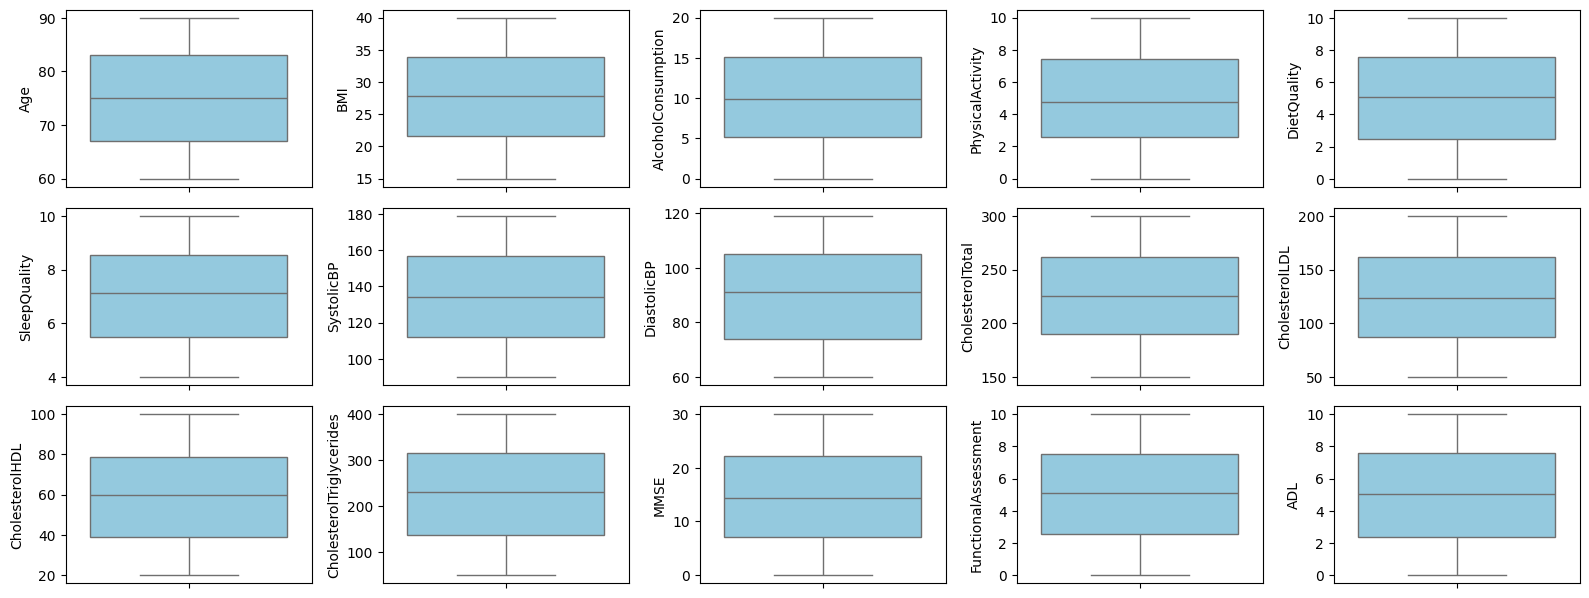

In [ ]:
numeric_cols = [
    "Age", "BMI", "AlcoholConsumption", "PhysicalActivity", "DietQuality",
    "SleepQuality", "SystolicBP", "DiastolicBP", "CholesterolTotal",
    "CholesterolLDL", "CholesterolHDL", "CholesterolTriglycerides",
    "MMSE", "FunctionalAssessment", "ADL"
]

#Outlier detection function (IQR method)
def detect_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers

#Show outlier counts
print("Number of outliers per selected column:\n")
for col in numeric_cols:
    outliers = detect_outliers(df, col)
    print(f"{col}: {len(outliers)}")

#Boxplots for selected numeric columns
plt.figure(figsize=(16, 10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(5, 5, i)
    sns.boxplot(y=df[col], color="skyblue")

plt.tight_layout()
plt.show()


Outlier analysis using boxplots and the IQR method shows that all numeric attributes are within normal ranges. No extreme values were found, so further outlier handling is not required.

## 3.Missing Values
We show the number of missing values per column. Columns with missing values will be handled during preprocessing.

In [ ]:
df.isnull().sum()

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


We checked for missing values using "df.isnull().sum()" and found none. Therefore, no further preprocessing is required for missing data.

##4. Class Label Distribution
We use Diagnosis as the class label. The counts below show the class distribution to consider later in modeling.


In [ ]:
TARGET_COL = "Diagnosis"
df[TARGET_COL].value_counts()

,count
Diagnosis,
0,1389
1,760


##5. Graphs

##5.1 Histogram

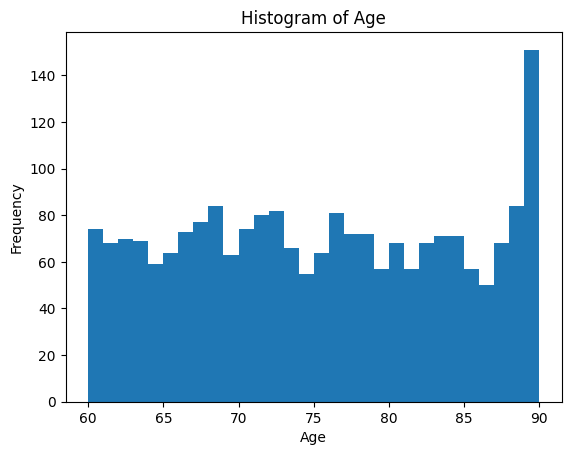

In [ ]:
df["Age"].plot(kind="hist", bins=30, title="Histogram of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

Description: The histogram shows that most patients are between 60 and 90 years old, with a noticeable peak at age 90, which occurs around 140 times. This indicates that the dataset is heavily skewed toward older ages, emphasizing the need to consider normalization and discretization during preprocessing.

##5.2 Scatter Plot

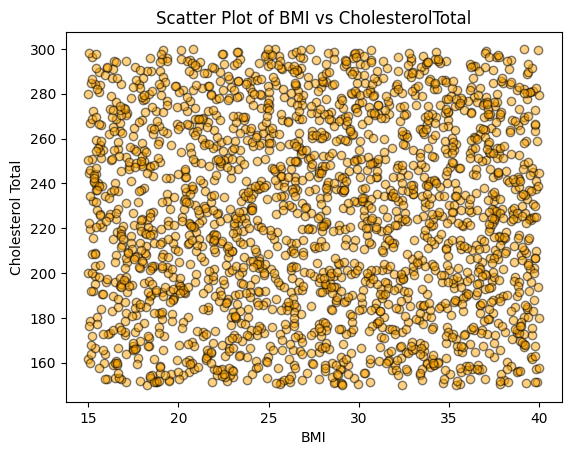

In [ ]:
plt.scatter(df["BMI"], df["CholesterolTotal"], alpha=0.5, c="orange", edgecolor="black")
plt.title("Scatter Plot of BMI vs CholesterolTotal")
plt.xlabel("BMI")
plt.ylabel("Cholesterol Total")
plt.show()

Description: The scatter plot shows that patients with higher BMI often have higher cholesterol values. This is important since both are risk factors linked to Alzheimer’s and overall brain health.This suggests preprocessing like outlier handling or normalization may be needed. The plot also confirms both features are relevant for analysis.

##5.3 Bar Plot

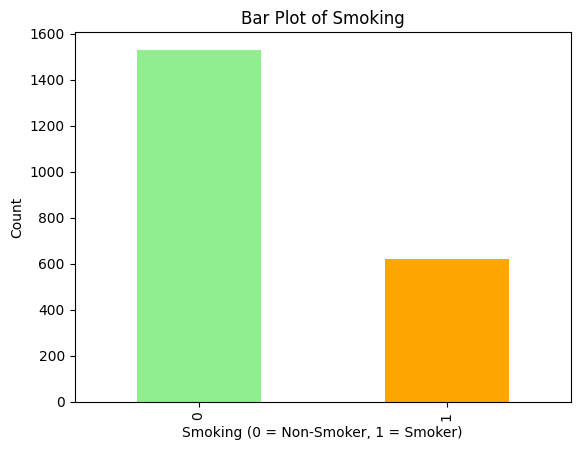

In [ ]:
df["Smoking"].value_counts().plot(
    kind="bar",
    title="Bar Plot of Smoking",
    color=["lightgreen", "orange"]
)
plt.xlabel("Smoking (0 = Non-Smoker, 1 = Smoker)")
plt.ylabel("Count")
plt.show()

Description: The plot shows that most patients are non-smokers, while a smaller portion are smokers. This imbalance suggests that the data may need preprocessing, such as normalization, discretization, or other techniques to make it suitable for analysis.

##5.4 Class Label Distribution

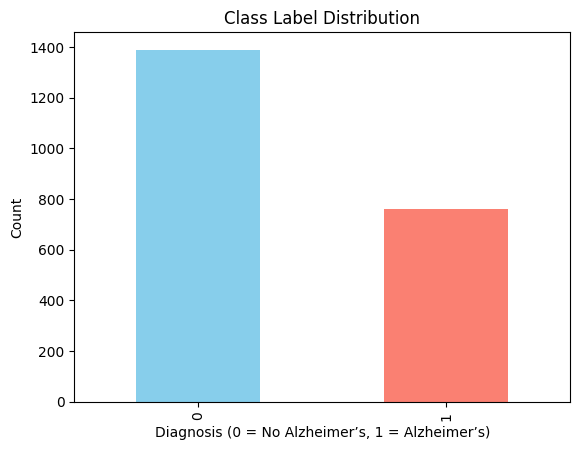

In [ ]:
df["Diagnosis"].value_counts().plot(
    kind="bar",
    title="Class Label Distribution",
    color=["skyblue", "salmon"]
)
plt.xlabel("Diagnosis (0 = No Alzheimer’s, 1 = Alzheimer’s)")
plt.ylabel("Count")
plt.show()

Description: The bar plot displays the distribution of the Diagnosis classes. Class 0 (No Alzheimer’s) is more frequent than class 1 (Alzheimer’s), showing a class imbalance. This highlights the need for preprocessing, such as feature selection to keep relevant attributes and normalization to scale numeric features for modeling.

# Part 2 :Data Preprocessing

### 1)Discretization


We transformed the continuous Age into a categorical feature AgeGroup using fixed bins:
<60, 60–69, 70–79, and 80+>. This represents age as interpretable ranges rather than raw numbers.

In [ ]:
df_raw = df.copy()
bins = [-np.inf, 60, 70, 80, np.inf]
labels = ['<60', '60–69', '70–79', '80+']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels, right=False)

df[['Age','AgeGroup']].sample(5)

,Age,AgeGroup
1071,84,80+
113,69,60–69
1867,89,80+
1903,79,70–79
103,88,80+


Converting continuous values into groups reduces noise and highlights clear patterns across age intervals

### 2)Normalization

We applied Min–Max normalization to continuous numerical features only, scaling them to [0, 1].
Identifier and categorical columns (PatientID, Age, AgeGroup, Gender, Ethnicity) and the target (Diagnosis) were excluded.

In [ ]:
exclude_cols = {'PatientID', 'Age', 'AgeGroup', 'Gender', 'Ethnicity', 'Diagnosis'}
num_cols = [c for c in df.select_dtypes(include='number').columns if c not in exclude_cols]

df[num_cols] = df[num_cols].astype(float)
scaler = MinMaxScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

df[num_cols].sample(5)

,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,...,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness
1622,0.000000,0.277669,0.0,0.308623,0.231253,0.414734,0.547150,0.0,1.0,1.0,...,0.256671,0.578426,1.0,0.0,0.815207,0.0,1.0,0.0,0.0,0.0
1135,0.333333,0.910350,0.0,0.481201,0.372075,0.072672,0.834132,1.0,0.0,0.0,...,0.480834,0.307330,0.0,1.0,0.862976,0.0,0.0,0.0,0.0,0.0
212,1.000000,0.452107,0.0,0.804634,0.690784,0.436069,0.040966,1.0,0.0,0.0,...,0.806961,0.098365,0.0,0.0,0.573695,0.0,0.0,0.0,0.0,0.0
1265,0.666667,0.696149,1.0,0.077010,0.443790,0.504929,0.193817,0.0,0.0,0.0,...,0.256748,0.414812,1.0,0.0,0.869966,0.0,0.0,0.0,0.0,1.0
1280,0.666667,0.261374,1.0,0.372850,0.622252,0.795417,0.017882,0.0,0.0,0.0,...,0.386401,0.692828,0.0,0.0,0.233466,1.0,0.0,0.0,0.0,0.0


### 3)Feature Selection


Categorical features were encoded using one-hot encoding (pd.get_dummies,drop_first=True).
The target Diagnosis was converted into numeric codes.
We then applied SelectKBest with the ANOVA F-test to select the top k=10 most relevant features correlated with the target.


In [ ]:
X = df.drop(columns=['Diagnosis'])
X = pd.get_dummies(X, drop_first=True)

y = df['Diagnosis'].astype('category').cat.codes

k = min(10, X.shape[1])
selector = SelectKBest(score_func=f_classif, k=k)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]

df_selected = df[selected_features.tolist() + ['Diagnosis']]
df_selected.sample(5)

,PatientID,EducationLevel,SleepQuality,Hypertension,CholesterolHDL,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Diagnosis
393,5144,0.666667,0.765311,1.0,0.888571,0.771252,0.662651,1.0,0.0,0.153675,1
611,5362,0.333333,0.078523,0.0,0.354842,0.380088,0.702552,0.0,1.0,0.485048,1
441,5192,0.666667,0.228320,0.0,0.574860,0.299573,0.295564,1.0,0.0,0.079424,1
1039,5790,0.666667,0.256644,0.0,0.567205,0.220328,0.175658,0.0,0.0,0.967389,0
698,5449,0.333333,0.475442,0.0,0.954455,0.117267,0.626174,0.0,0.0,0.772735,0


This reduced the dimensionality of the dataset, removed less informative attributes, and kept only the strongest predictors.

#Snapshot for the raw and the processed dataset


In [ ]:
raw_df = df_raw.copy()
raw_df.to_csv("Raw_dataset.csv", index=False)

print("Snapshot of Raw Dataset:")
display(raw_df.head(5))

Snapshot of Raw Dataset:


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [ ]:
processed_df = df_selected.copy()
processed_df.to_csv("Preprocessed_dataset.csv", index=False)

print("Snapshot of Preprocessed Dataset:")
display(processed_df.head(5))

Snapshot of Preprocessed Dataset:


,PatientID,EducationLevel,SleepQuality,Hypertension,CholesterolHDL,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Diagnosis
0,4751,0.666667,0.837564,0.0,0.171039,0.715606,0.652102,0.0,0.0,0.172486,0
1,4752,0.000000,0.525021,0.0,0.738026,0.687251,0.712108,0.0,0.0,0.259154,0
2,4753,0.333333,0.945597,0.0,0.622290,0.245145,0.589697,0.0,0.0,0.711936,0
3,4754,0.333333,0.731994,0.0,0.605851,0.466410,0.896823,0.0,1.0,0.648094,0
4,4755,0.000000,0.265892,0.0,0.461019,0.450619,0.604699,0.0,0.0,0.001341,0



- Raw Dataset: This is the original dataset before any preprocessing. It was saved as Raw_dataset.csv to serve as a baseline reference.  
- Processed Dataset: This is the final dataset after applying discretization, normalization, and feature selection. It was saved as Preprocessed_dataset.csv and contains only the selected features plus the target Diagnosis.